# 현지실사 예측 모형
<img src = 'https://images.unsplash.com/photo-1564048171305-0dce5c555dbb?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Mnx8Y2xvbmV8ZW58MHx8MHx8&auto=format&fit=crop&w=500&q=60'>

In [152]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
#pd.read_pickle(path + '/data_01_대장.pkl').to_excel(path + '/data_01_대장.xlsx')

1689

,A02_국가코드,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,,
CN000095375,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,CN,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,VN,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,JP,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,TH,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,DE,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000418,US,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000318,US,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False


<AxesSubplot:>

적합     83.362937
부적합    16.637063
Name: target, dtype: float64

적합     1408
부적합     281
Name: target, dtype: int64

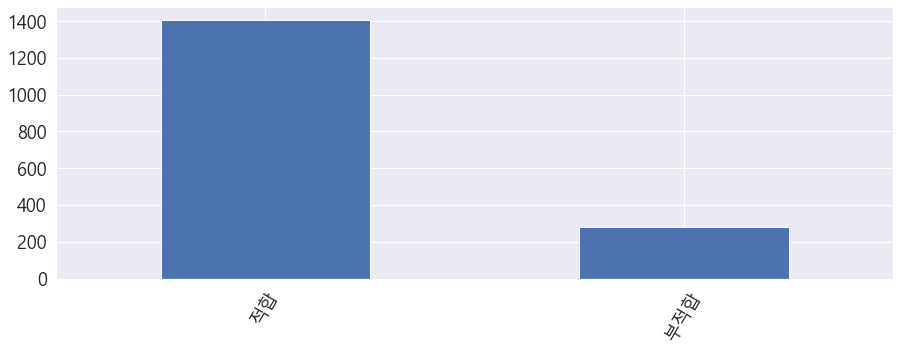

In [153]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
data = pd.read_pickle(path + '/data_01_대장.pkl').set_index('해외제조업소_코드')
len(set(data.index))
data
data['target'].map({False: '적합', True: '부적합'}).value_counts().plot(rot =60, kind='bar', figsize=(15,5), fontsize=18)
data['target'].map({False: '적합', True: '부적합'}).value_counts(normalize=True)*100
data['target'].map({False: '적합', True: '부적합'}).value_counts()

In [154]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        #tf.loc[col, 'False 비율']  =  df[col].value_counts(normalize=True).loc[1]
        
    return tf

In [155]:
summary(data)

,데이터형태(dtypes),결측치 수(null),결측치 비율(%),고유값 수(nunique),자료 내용(contents)
A02_국가코드,object,0,0.0,45,['CN' 'VN' 'JP' 'TH' 'ID']
업소명,bool,0,0.0,1,[ True]
대표자성명,bool,0,0.0,2,[ True False]
주소,bool,0,0.0,2,[ True False]
전화번호,bool,0,0.0,2,[ True False]
이메일,bool,0,0.0,2,[ True False]
회사이메일,bool,0,0.0,2,[False True]
팩스,bool,0,0.0,2,[False True]
인증,bool,0,0.0,2,[False True]
공식인증,bool,0,0.0,2,[False True]


## 국가코드를 한글명으로 공통코드에서 MAPPING

In [156]:
path =r'D:\smart food\현지실사\2022_2_현지실사\코드테이블'
match = pd.read_excel(path + '/CM_CMMN_CODE 공통코드.xlsx', usecols = ['CMMN_CL_CODE', 'CMMN_CODE', 'CMMN_CODE_NM'])
match = match[match['CMMN_CL_CODE'] == 'MG004']
match = dict(zip(match.CMMN_CODE, match.CMMN_CODE_NM))

In [157]:
data['A02_국가코드'] = data['A02_국가코드'].map(match)

<AxesSubplot:>

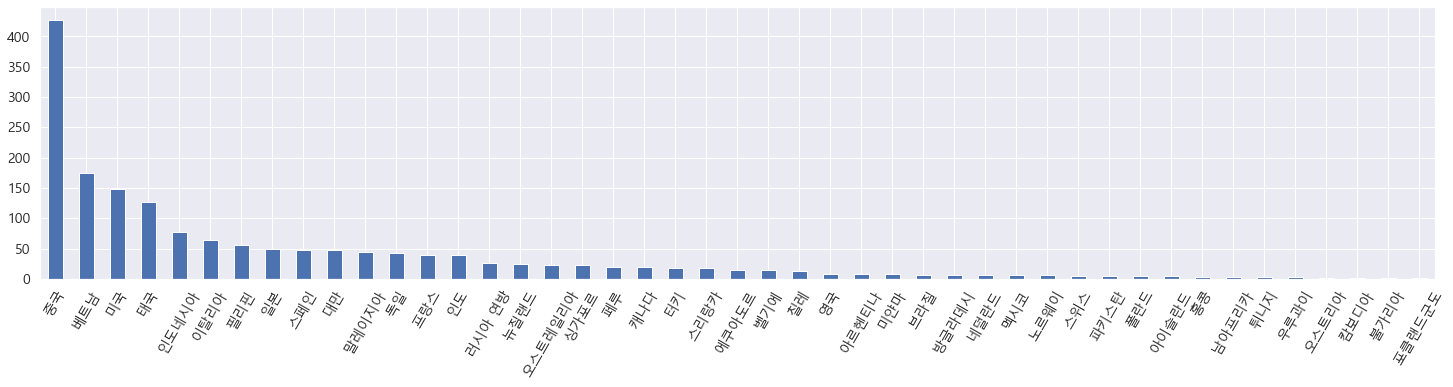

In [158]:
data['A02_국가코드'].value_counts().plot(kind='bar', rot=60, figsize=(25,5), fontsize=14)
#data['A02_국가코드'].map(match).value_counts().plot(kind='bar', rot=60, figsize=(25,5), fontsize=14)

<AxesSubplot:xlabel='A02_국가코드'>

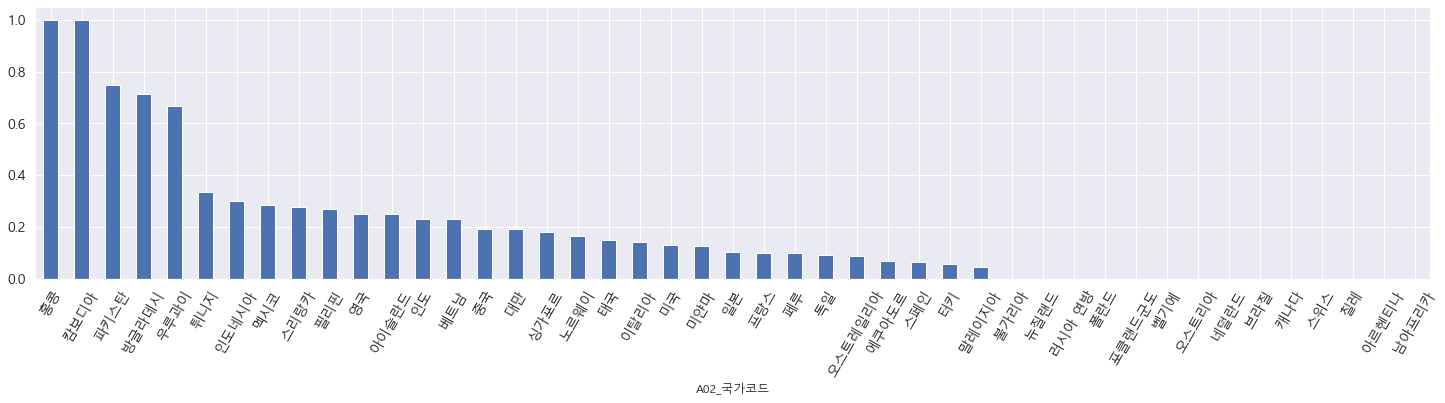

In [159]:
data.groupby('A02_국가코드')['target'].mean().sort_values(ascending=False).plot(kind='bar', rot=60, figsize=(25,5), fontsize=14)

# Theil_U

In [160]:
import math
import scipy.stats as ss
from collections import Counter

def conditional_entropy(x,y):
    # entropy of x given y
    y_counter = Counter(y)
    xy_counter = Counter(list(zip(x,y)))
    total_occurrences = sum(y_counter.values())
    entropy = 0
    for xy in xy_counter.keys():
        p_xy = xy_counter[xy] / total_occurrences
        p_y = y_counter[xy[1]] / total_occurrences
        entropy += p_xy * math.log(p_y/p_xy)
    return entropy

def theil_u(x,y):
    s_xy = conditional_entropy(x,y)
    x_counter = Counter(x)
    total_occurrences = sum(x_counter.values())
    p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
    s_x = ss.entropy(p_x)
    if s_x == 0:
        return 1
    else:
        return (s_x - s_xy) / s_x

In [161]:
columns = data.columns
theilu = pd.DataFrame(index=['target'], columns= columns)


def cat_corr (df):
    
    for j in range(0,len(columns)):
        u = theil_u(df['target'].tolist(),df[columns[j]].tolist())
        theilu.loc[:,columns[j]] = u
    theilu.fillna(value=np.nan,inplace=True)

    plt.figure(figsize=(30,2))
    sns.set(font_scale=1.4)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    sns.heatmap(theilu,annot=True,fmt='.4f', annot_kws={"size": 16})

    plt.show()

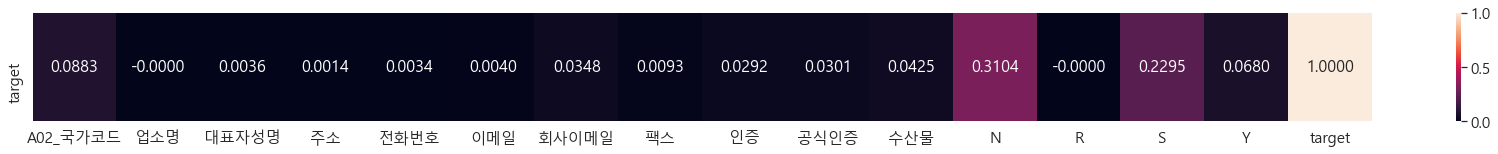

In [162]:
cat_corr(data)

### Alone in the woods: Using Theil's U for survival
- https://www.kaggle.com/code/shakedzy/alone-in-the-woods-using-theil-s-u-for-survival/notebook

Text(-0.35000000000000003, 91, '81')

Text(0.6500000000000001, 1337, '1327')

Text(0.049999999999999975, 191, '181')

Text(1.0499999999999998, 110, '100')

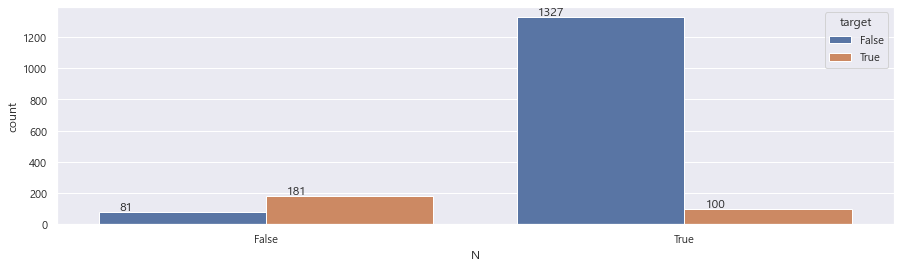

In [168]:
sns.set(rc={'figure.figsize':(15,4)})

plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  #한글 폰트 사용시 마이너스 폰트 깨짐 해결
ax=sns.countplot(x='N',hue='target',data=data)
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.05, patch_height+10))
plt.show()

In [123]:
from sklearn.feature_selection import chi2, SelectKBest

import category_encoders as ce
woe = ce.woe.WOEEncoder()
cat = ce.cat_boost.CatBoostEncoder()
tm = ce.target_encoder.TargetEncoder()
data['A02_국가코드'] = tm.fit_transform(data['A02_국가코드'], data.target)

In [124]:
data

,A02_국가코드,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,,
CN000095375,0.192037,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,0.192037,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,0.229885,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,0.102041,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,0.149606,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,0.093023,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000418,0.128378,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
US000000318,0.128378,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False


In [93]:
'''
    for feature in data.columns:
    uniq = np.unique(data[feature])
    print('{}: {} distinct values -  {}'.format(feature,len(uniq),uniq))
'''

"\n    for feature in data.columns:\n    uniq = np.unique(data[feature])\n    print('{}: {} distinct values -  {}'.format(feature,len(uniq),uniq))\n"

In [127]:
data.drop(['업소명','R'], axis=1, inplace=True)

X = data.iloc[:, :-1]
X.shape
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

(1689, 13)

0.9171597633136095

              precision    recall  f1-score   support

       False       0.93      0.97      0.95       279
        True       0.82      0.68      0.74        59

    accuracy                           0.92       338
   macro avg       0.88      0.82      0.85       338
weighted avg       0.91      0.92      0.91       338



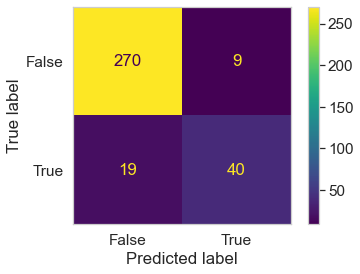

In [128]:
from sklearn import ensemble 
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report
# 파이프라인
from sklearn.pipeline import Pipeline, make_pipeline
# 시각화 툴
import scikitplot as skplt

rf = ensemble.RandomForestClassifier(random_state=11)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

# 중복데이터 제거

<img src = 'https://images.unsplash.com/photo-1528812969535-4bcefc071532?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Nnx8c2FtZXxlbnwwfHwwfHw%3D&auto=format&fit=crop&w=500&q=60' width=350 height=200>

## 1. 특성변수와 target이 모두 동일한 제조회사 걸러내고 예측 모형

In [129]:
print(f'Known food company: {len(data.index)} \n Unique food company: {len(data.drop_duplicates().index)}')
print(f'Known(중복) food company')
print('*'*100)
data.index[data.duplicated()]
print(f'Unique food company')
data.drop_duplicates().index

Known food company: 1689 
 Unique food company: 450
Known(중복) food company
****************************************************************************************************


Index(['CN000010833', 'VN000002079', 'CN000001898', 'VN000001940',
       'IT000000046', 'JP000004505', 'IT000001024', 'TH000002096',
       'CN000002847', 'BG000000004',
       ...
       'PK000000847', 'TH000002005', 'CN000096112', 'US000032073',
       'CN000016328', 'VN000002384', 'DE000000001', 'US000000418',
       'US000000318', 'PH000000007'],
      dtype='object', name='해외제조업소_코드', length=1239)

Unique food company


Index(['CN000095375', 'VN000000420', 'JP000002818', 'TH000001271',
       'VN000000995', 'ID000001276', 'US000001815', 'TH000000292',
       'CN000000455', 'TH000001597',
       ...
       'PH000003472', 'NZ000003242', 'VN000001121', 'US000032986',
       'US000032988', 'CN000099657', 'MM000001465', 'ID000001242',
       'NO000001098', 'PH000000010'],
      dtype='object', name='해외제조업소_코드', length=450)

In [130]:
mypd = pd.DataFrame()
r = 'CN000010833'
data[data.index == r]
for row in data.index:
    if data.loc[r, :].eq(data.loc[row, :]).sum() == len(data.columns): # 컬럼의 값이 동일하면 모두 True로 총합이 13
        mypd = mypd.append(data[data.index == row])
mypd.head()
mypd['target'].value_counts(dropna=False)

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,
CN000010833,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False


,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,
CN000095375,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False
CN000010833,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False
CN000002847,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False
CN000002744,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False
CN000002452,0.192037,True,True,True,True,False,False,False,False,False,True,False,False,False


False    31
Name: target, dtype: int64

In [134]:
data.shape
data_01 = data[~data.duplicated()]
data_01.shape
data_01['target'].map({False: '적합', True: '부적합'}).value_counts(normalize=True)
data_01['target'].map({False: '적합', True: '부적합'}).value_counts()

(1689, 14)

(450, 14)

적합     0.657778
부적합    0.342222
Name: target, dtype: float64

적합     296
부적합    154
Name: target, dtype: int64

0.7111111111111111

              precision    recall  f1-score   support

       False       0.77      0.77      0.77        57
        True       0.61      0.61      0.61        33

    accuracy                           0.71        90
   macro avg       0.69      0.69      0.69        90
weighted avg       0.71      0.71      0.71        90



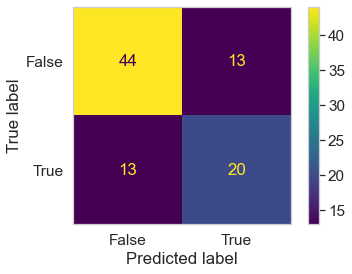

In [133]:
X = data_01.iloc[:, :-1]
y = data_01.target

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

rf = ensemble.RandomForestClassifier(random_state=11)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

## 특성변수는 같은데 Target이 다른 회사

In [135]:
print(f'Known company: {len(data_01.index)}')
a = len(data_01.drop_duplicates(subset=data_01.drop(['target'],axis=1).columns))
print(f'Known company with same features(taget은 다른데 입력변수 동일) : {len(data_01) - a}')

Known company: 450
Known company with same features(taget은 다른데 입력변수 동일) : 66


In [136]:
sample = data_01.drop(['target'],axis=1)
sample[sample.duplicated()]

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y
해외제조업소_코드,,,,,,,,,,,,,
CN000000349,0.192037,True,True,True,True,False,True,False,False,False,True,False,False
CN000000055,0.192037,True,True,True,True,True,True,True,True,False,True,False,False
VN000000373,0.229885,True,True,True,True,True,True,True,True,False,True,False,False
US000001688,0.128378,True,True,True,True,True,False,False,False,False,True,False,False
IT000000299,0.140625,True,True,True,True,True,False,True,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
IS000000256,0.246034,True,True,True,True,True,False,False,False,True,True,False,False
VN000008628,0.229885,True,True,True,True,False,True,True,True,True,True,False,False
VN000008405,0.229885,True,True,True,True,False,True,False,False,True,False,True,False


In [137]:
upd = pd.DataFrame()
r = 'CN000000349'
data_01[data_01.index == r]
for row in sample.index:
    if sample.loc[r, :].eq(sample.loc[row, :]).sum() == len(sample.columns): # 컬럼의 값이 동일하면 모두 True로 총합이 13
        upd = upd.append(data_01[data_01.index == row])
        
upd

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,
CN000000349,0.192037,True,True,True,True,False,True,False,False,False,True,False,False,False


,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,
CN000000905,0.192037,True,True,True,True,False,True,False,False,False,True,False,False,True
CN000000349,0.192037,True,True,True,True,False,True,False,False,False,True,False,False,False


In [138]:
print('target까지 중복되는 데이터')
data_01[data_01.duplicated()]

print('target은 다르지만 입력변수가 중복 안되는 데이터')
data_02 = data_01[~data_01.drop(['target'],axis=1).duplicated()]
data_02.shape

target까지 중복되는 데이터


,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,


target은 다르지만 입력변수가 중복 안되는 데이터


(384, 14)

In [140]:
data_02.shape
data_02['target'].map({False: '적합', True: '부적합'}).value_counts(normalize=True)
data_02['target'].map({False: '적합', True: '부적합'}).value_counts()

(384, 14)

적합     0.716146
부적합    0.283854
Name: target, dtype: float64

적합     275
부적합    109
Name: target, dtype: int64

0.8441558441558441

              precision    recall  f1-score   support

       False       0.90      0.87      0.89        54
        True       0.72      0.78      0.75        23

    accuracy                           0.84        77
   macro avg       0.81      0.83      0.82        77
weighted avg       0.85      0.84      0.85        77



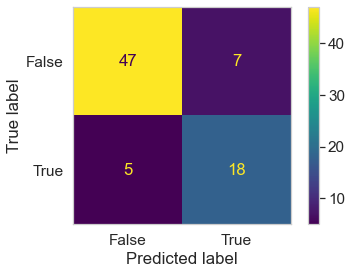

In [139]:
X = data_02.iloc[:, :-1]
y = data_02.target

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

rf = ensemble.RandomForestClassifier(random_state=11)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

# 최재석박사 작업분

In [36]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
data = pd.read_pickle(path + '/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


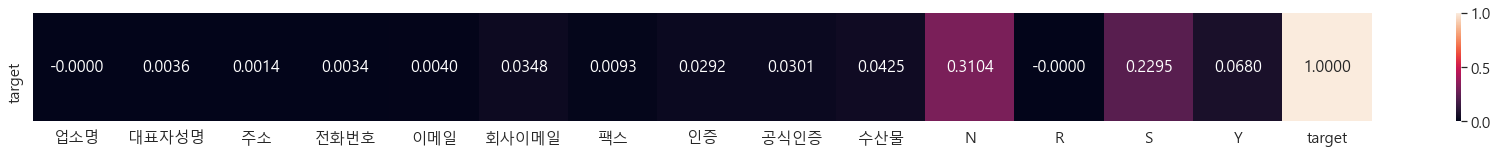

In [37]:
columns = data.columns
theilu = pd.DataFrame(index=['target'], columns= columns)
cat_corr(data)

In [38]:
from sklearn.feature_selection import chi2

In [39]:
X = data.iloc[:, :-1]
y = data.target
chi2_selector = SelectKBest(chi2, k=12)
chi2_selector.fit(X, y)
chi2_scores = pd.DataFrame(list(zip(data.columns, chi2_selector.scores_, chi2_selector.pvalues_)), columns=['컬럼', '카이제곱값', 'p_value'])
chi2_scores.fillna(0).set_index('컬럼').sort_values('카이제곱값')#.plot(kind='bar', rot=360, figsize=(25,5), fontsize=18)

SelectKBest(k=12, score_func=<function chi2 at 0x000001D5AA87D8B0>)

,카이제곱값,p_value
컬럼,,
업소명,0.000000,1.000000e+00
R,0.000000,0.000000e+00
주소,0.023560,8.780106e-01
전화번호,0.094741,7.582347e-01
대표자성명,0.101696,7.498041e-01
이메일,0.116359,7.330179e-01
팩스,6.439360,1.116188e-02
회사이메일,20.763620,5.196070e-06
인증,25.883677,3.626227e-07


In [40]:
best_features =12
def Chi_selector(X, y):
    chi_selector = SelectKBest(chi2, k=best_features)
    chi_selector.fit(X, y)
    chi_support = chi_selector.get_support()
    chi_feature = X.loc[:, chi_support].columns.tolist()
    return chi_feature, chi_support
chi_feature, chi_support = Chi_selector(X, y)
','.join(chi_feature)
chi_support

'대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y'

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True])

In [41]:
data.corr().fillna(0)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
업소명,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
대표자성명,0.0,1.000000,0.024290,0.886230,0.853757,0.177161,0.150163,0.113389,0.111984,-0.109535,0.155574,0.0,0.043816,-0.244464,0.049803
주소,0.0,0.024290,1.000000,0.024965,0.022997,0.023902,0.058362,0.062591,0.061697,-0.070858,0.059397,0.0,-0.043935,-0.036775,-0.038373
전화번호,0.0,0.886230,0.024965,1.000000,0.914169,0.198397,0.171169,0.119823,0.118460,-0.103232,0.159128,0.0,0.043265,-0.248601,0.048667
이메일,0.0,0.853757,0.022997,0.914169,1.000000,0.205890,0.154980,0.124349,0.122934,-0.131036,0.148784,0.0,0.044899,-0.236587,0.052019
회사이메일,0.0,0.177161,0.023902,0.198397,0.205890,1.000000,-0.082495,0.265974,0.273270,-0.210535,0.202374,0.0,-0.112798,-0.159697,-0.179560
팩스,0.0,0.150163,0.058362,0.171169,0.154980,-0.082495,1.000000,0.023234,0.023115,0.249913,0.106227,0.0,-0.074694,-0.069388,-0.091747
인증,0.0,0.113389,0.062591,0.119823,0.124349,0.265974,0.023234,1.000000,0.988624,-0.214112,0.241672,0.0,-0.142463,-0.183473,-0.156191
공식인증,0.0,0.111984,0.061697,0.118460,0.122934,0.273270,0.023115,0.988624,1.000000,-0.215180,0.244446,0.0,-0.144583,-0.185128,-0.158318
수산물,0.0,-0.109535,-0.070858,-0.103232,-0.131036,-0.210535,0.249913,-0.214112,-0.215180,1.000000,0.081340,0.0,-0.090737,-0.021860,-0.173017


### 업소명과 R 변수를 제거

In [42]:
data.drop(['업소명','R'], axis=1, inplace=True)
X = data.iloc[:, :-1]
y = data.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size = 0.2, random_state=12)

0.9260355029585798

              precision    recall  f1-score   support

       False       0.94      0.97      0.96       279
        True       0.85      0.69      0.77        59

    accuracy                           0.93       338
   macro avg       0.90      0.83      0.86       338
weighted avg       0.92      0.93      0.92       338



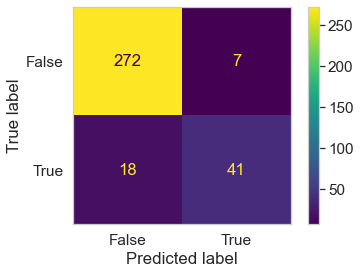

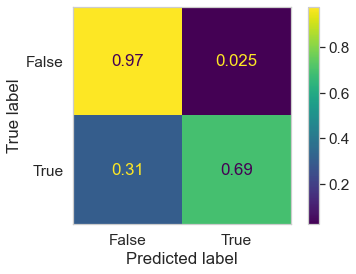

In [43]:
from sklearn import ensemble 
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report
# 파이프라인
from sklearn.pipeline import Pipeline, make_pipeline
# 시각화 툴
import scikitplot as skplt

rf = ensemble.RandomForestClassifier(random_state=11)
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)
plot_confusion_matrix(rf, X_test, y_test, normalize='true')

In [44]:
rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
rf.fit(X_train, y_train)
y_predict = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print(f'Mean accuracy score: {accuracy:.3}')
print(f'Out-of-bag score estimate: {rf.oob_score_:.3}')
print(classification_report(y_test, y_predict))

NameError: name 'RandomForestClassifier' is not defined

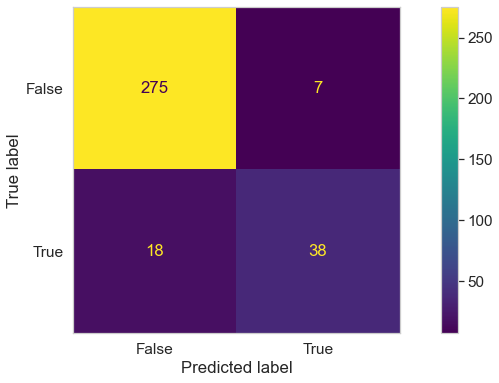

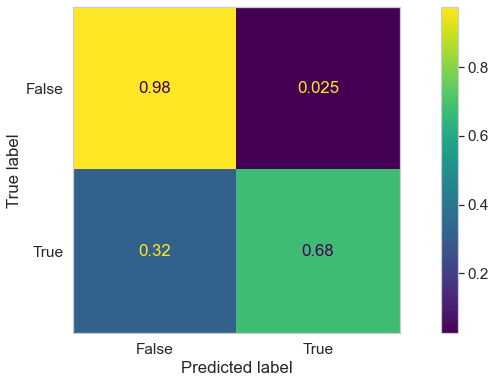

In [175]:
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)
plot_confusion_matrix(rf, X_test, y_test, normalize='true')

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

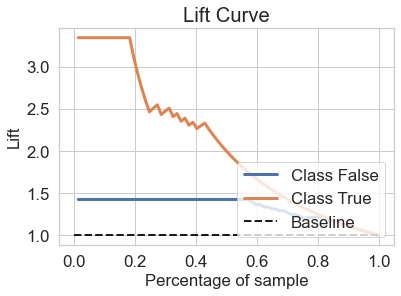

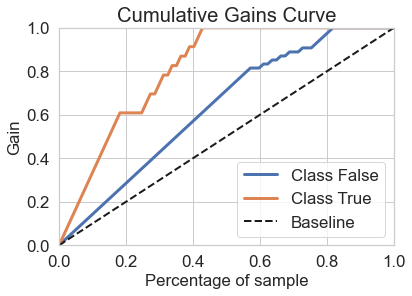

In [141]:
y_proba = rf.predict_proba(X_test)
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

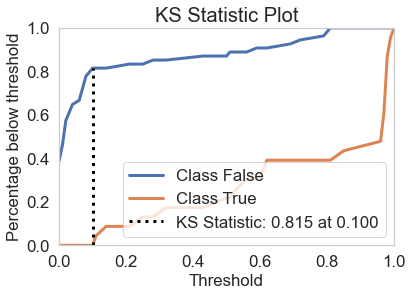

In [142]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

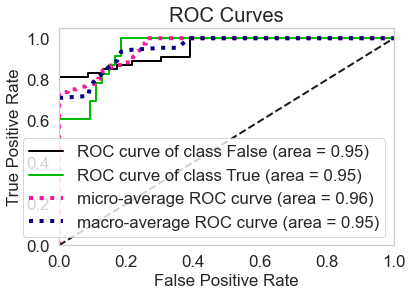

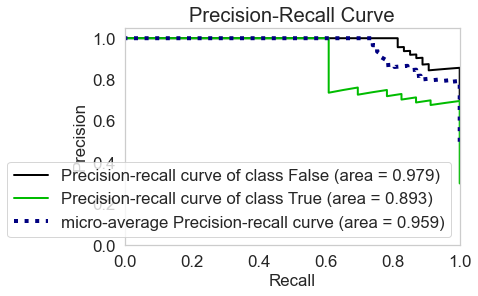

In [143]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [144]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

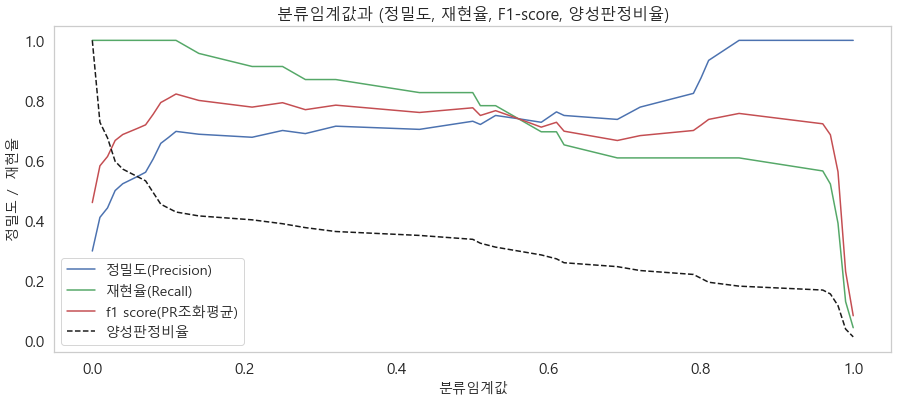

In [145]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

  0%|          | 0/1 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

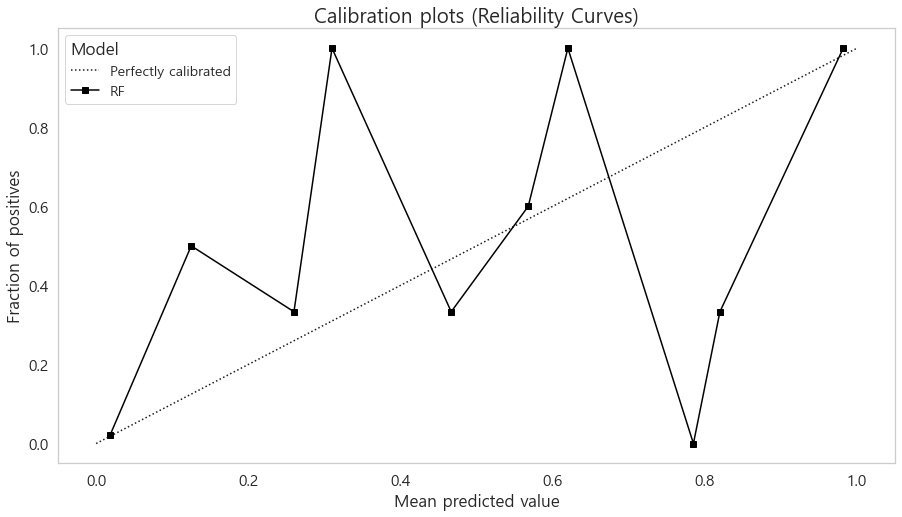

In [146]:
classifiers = {}
#classifiers.update({'GNB': GaussianNB()})
#classifiers.update({'LGR': LogisticRegression(class_weight='balanced')})
#classifiers.update({'SVC': SVC(probability=True)})
classifiers.update({'RF': ensemble.RandomForestClassifier(n_estimators=100, class_weight='balanced')})
from tqdm import tqdm_notebook
classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    y_proba = classifier.fit(X_train, y_train).predict_proba(X_test)
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_test, probas_list, classifier_labels, figsize=(15,8))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

(array([44.,  2.,  3.,  1.,  3.,  5.,  1.,  2.,  3., 13.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

(array([13.,  3.,  2.,  1.,  5.,  3.,  2.,  2.,  2., 44.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

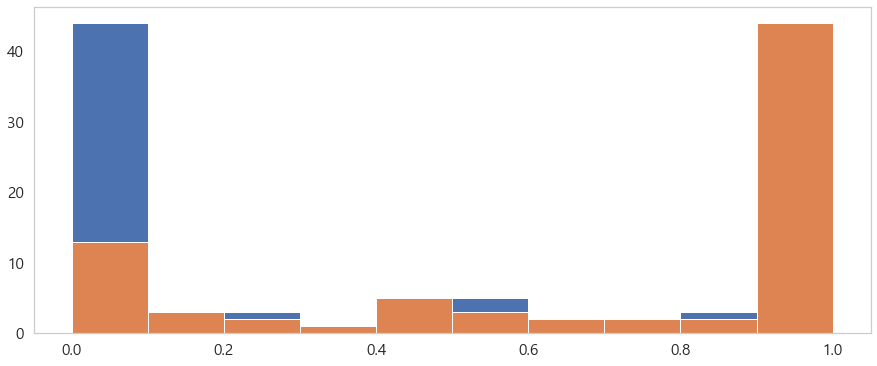

In [147]:
plt.hist(y_proba[:, 1]) 
plt.hist(y_proba[:, 0]) 

In [148]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])
data

,Predicted Probability,True Label
0,0.56,1.0
1,0.00,0.0
2,0.07,0.0
3,0.04,0.0
4,0.08,0.0
...,...,...
72,0.02,0.0
73,0.00,0.0
74,0.04,0.0
75,0.00,0.0


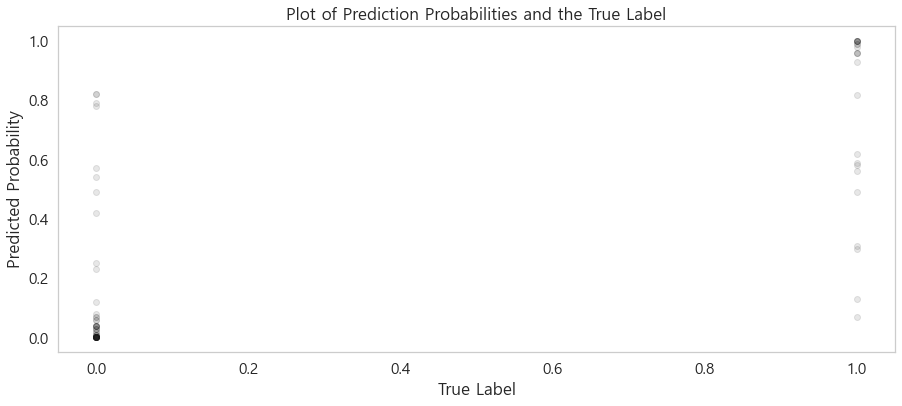

In [149]:
ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.1},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

In [151]:
datamelted = pd.melt(data, "True Label", var_name="Predicted Probability")
ax = sns.stripplot(x="value", y="Predicted Probability",
                   hue='True Label', jitter=0.5,
                   data=datamelted.sample(100, random_state=13)).set_title('Plot of Prediction Probabilities and the True Label')

ValueError: Cannot take a larger sample than population when 'replace=False'

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)

<Figure size 1800x360 with 0 Axes>

Text(0, 0.5, 'Features Importance')

Text(0.5, 1.0, '변수 중요도')

([<matplotlib.axis.XTick at 0x1d5ab67ea60>,
 [Text(0, 0, '대표자성명'),
  Text(1, 0, '주소'),
  Text(2, 0, '전화번호'),
  Text(3, 0, '이메일'),
  Text(4, 0, '회사이메일'),
  Text(5, 0, '팩스'),
  Text(6, 0, '인증'),
  Text(7, 0, '공식인증'),
  Text(8, 0, '수산물'),
  Text(9, 0, 'N'),
  Text(10, 0, 'S'),
  Text(11, 0, 'Y')])

<BarContainer object of 12 artists>

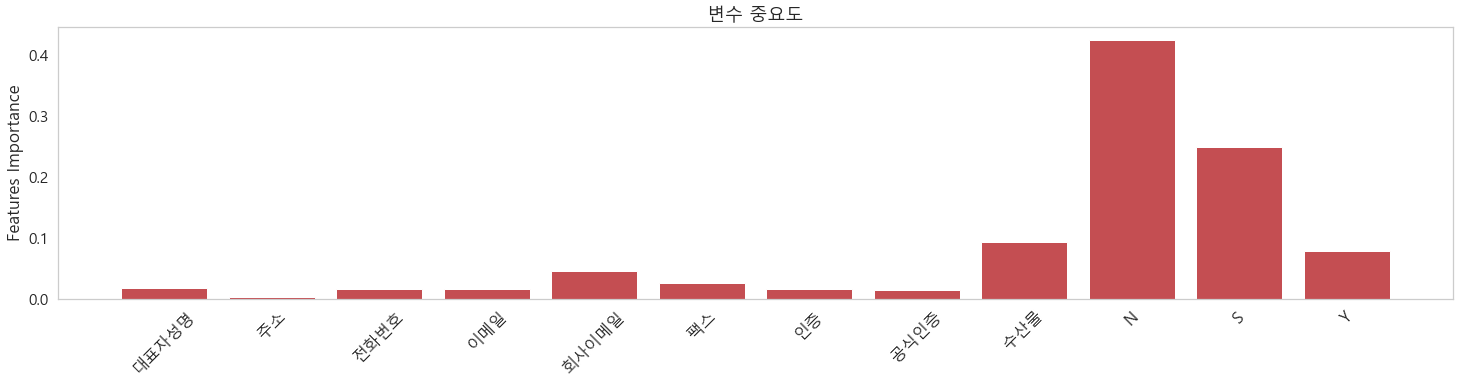

In [58]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, 
                                                  stratify= y, random_state=11)
dt = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
dt.fit(X, y)
plt.figure(figsize=(25,5)); plt.ylabel('Features Importance')
plt.title('변수 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), dt.feature_importances_, color='r')

<Figure size 1800x432 with 0 Axes>

Text(0, 0.5, 'Features Permutation Importance')

Text(0.5, 1.0, '의사결정트리의 변수 Permutation 중요도')

([<matplotlib.axis.XTick at 0x1d5aa4a35b0>,
 [Text(0, 0, '대표자성명'),
  Text(1, 0, '주소'),
  Text(2, 0, '전화번호'),
  Text(3, 0, '이메일'),
  Text(4, 0, '회사이메일'),
  Text(5, 0, '팩스'),
  Text(6, 0, '인증'),
  Text(7, 0, '공식인증'),
  Text(8, 0, '수산물'),
  Text(9, 0, 'N'),
  Text(10, 0, 'S'),
  Text(11, 0, 'Y')])

<BarContainer object of 12 artists>

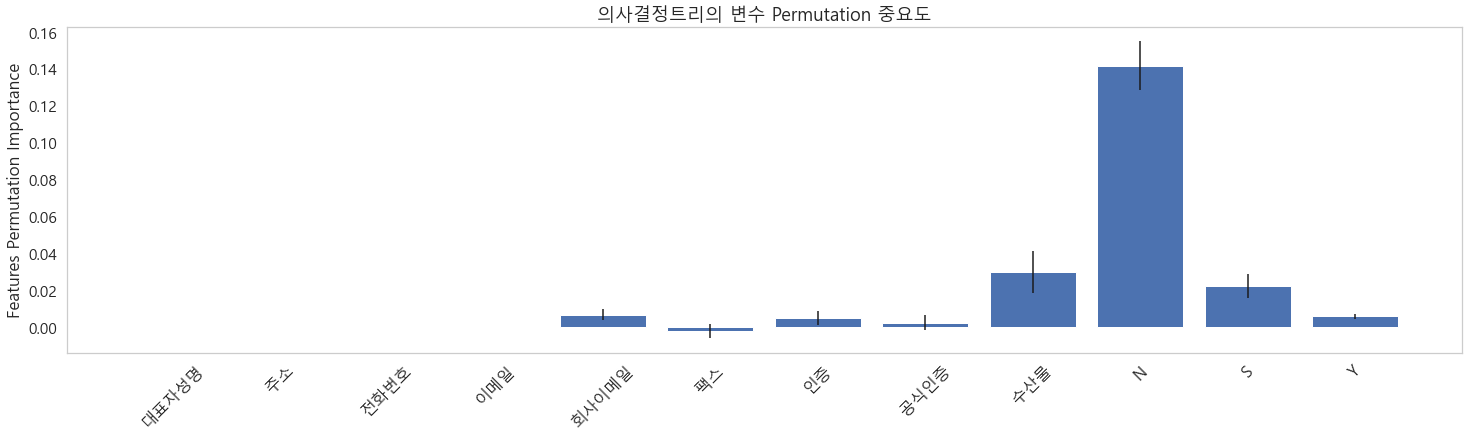

In [59]:
from sklearn.inspection import permutation_importance
result = permutation_importance(dt, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
feature_names = [f'feature {i}' for i in range(X.shape[1])]
forest_importances = pd.Series(result.importances_mean, index=feature_names)
plt.figure(figsize=(25,6)); plt.ylabel('Features Permutation Importance')
plt.title('의사결정트리의 변수 Permutation 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), forest_importances, yerr=result.importances_std, color='b')

In [60]:
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
params = {
    'criterion' :['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth' : np.arange(1,15),
    'min_samples_split': np.arange(0.005, 0.1, 0.001),
    'min_samples_leaf': [0.005, 0.01, 0.05, 0.10], # np.arange(0.005, 0.1, 0.001)
    'max_features': ['auto', 'sqrt', 'log2'],
}
np.random.seed(1111)
kf = KFold(n_splits=2)
model = DecisionTreeClassifier(random_state=11)
grid = RandomizedSearchCV(model, params, cv=kf, n_iter=50, 
                          scoring = 'recall_macro', verbose =True)
grid.fit(X_train, y_train)
print(f'optimal parameter: {grid.best_params_}')

Fitting 2 folds for each of 50 candidates, totalling 100 fits


RandomizedSearchCV(cv=KFold(n_splits=2, random_state=None, shuffle=False),
                   estimator=DecisionTreeClassifier(random_state=11), n_iter=50,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [0.005, 0.01, 0.05,
                                                             0.1],
                                        'min_samples_split': array([0.005,...
       0.05 , 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058,
       0.059, 0.06 , 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067,
       0.068, 0.069, 0.07 , 0.071, 0.072, 0.073, 0.074, 0.075, 0.076,
       0.077, 0.078, 0.079, 0.08 , 0.081, 0.082, 0.083, 0.084, 0.085,
       0.086, 0.087, 0.088, 0.089, 0.09 , 0.091, 0.092, 0.093, 0.094,
       0.095, 0.096, 0.097, 0.098, 0.099]),
                                        'splitter': ['best', 'random']},
                   scoring='recall_macro', verbose=True)

optimal parameter: {'splitter': 'best', 'min_samples_split': 0.019, 'min_samples_leaf': 0.005, 'max_features': 'auto', 'max_depth': 4, 'criterion': 'entropy'}


In [61]:
model= DecisionTreeClassifier(random_state=11).set_params(**grid.best_params_)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, max_features='auto',
                       min_samples_leaf=0.005, min_samples_split=0.019,
                       random_state=11)

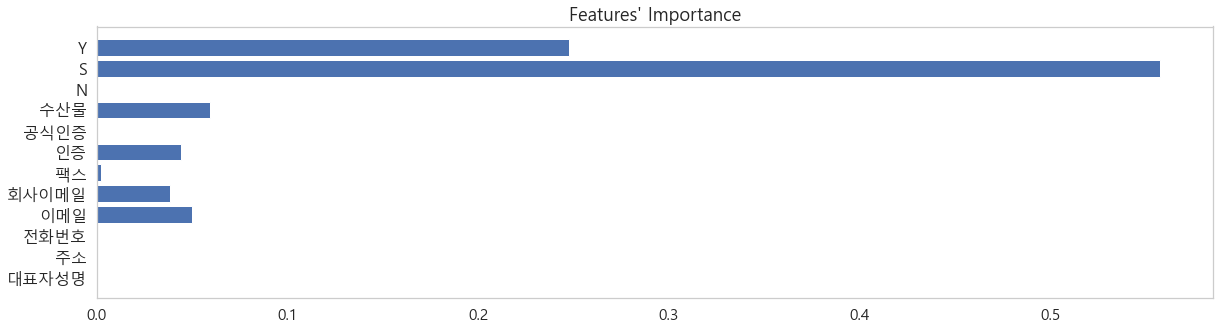

In [62]:
def plot_feature_importances(model):
    fig, ax = plt.subplots(1,1,figsize=(20,5))
    plt.barh(range(X_train.shape[1]), model.feature_importances_, align='center')
    plt.yticks(np.arange(X_train.shape[1]), X_train.columns, fontsize=16)
    plt.title("Features' Importance", fontsize=18)
    
plot_feature_importances(model)

# Pycaret

In [2]:
# https://pycaret.gitbook.io/docs/#classification
# 준비
from pycaret.classification import *
import pandas as pd

In [29]:
data = pd.read_pickle('../working_ml/data_01_대장.pkl').reset_index(drop=True).iloc[:,2:]
data

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
0,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
1,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
2,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
3,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
4,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1685,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False
1686,True,True,True,True,True,True,True,True,True,False,True,False,False,False,False
1687,True,True,True,True,True,True,False,True,True,False,True,False,False,False,False


In [30]:
# data.drop(['업소명','R','N','S'], axis=1, inplace=True)
data.drop(['업소명','R'], axis=1, inplace=True)

In [31]:
data.corr().shape

(13, 13)

In [32]:
train = data.sample(frac=0.8)
test = data[~data.index.isin(train.index)]

In [33]:
train.shape, test.shape

((1351, 13), (338, 13))

In [34]:
clf1 = setup(data = train, target = 'target', silent=True, fix_imbalance=True)

,Description,Value
0,session_id,344
1,Target,target
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(1351, 13)"
5,Missing Values,False
6,Numeric Features,0
7,Categorical Features,12
8,Ordinal Features,False
9,High Cardinality Features,False


In [35]:
# model training and selection
# best = compare_models()
# best = compare_models(include=['knn'])
best = compare_models(exclude=['knn','qda','dummy'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.8931,0.0000,0.6239,0.7190,0.6595,0.5976,0.6047,0.0130
lda,Linear Discriminant Analysis,0.8931,0.8603,0.6239,0.7190,0.6595,0.5976,0.6047,0.0140
ada,Ada Boost Classifier,0.8856,0.8583,0.6474,0.6908,0.6570,0.5897,0.5971,0.0700
nb,Naive Bayes,0.8742,0.8581,0.6294,0.7031,0.6383,0.5670,0.5840,0.0140
lr,Logistic Regression,0.8739,0.8562,0.6665,0.6585,0.6426,0.5689,0.5818,0.0210
lightgbm,Light Gradient Boosting Machine,0.8634,0.8649,0.7107,0.6017,0.6403,0.5583,0.5693,0.0340
rf,Random Forest Classifier,0.8613,0.8614,0.7044,0.5997,0.6367,0.5535,0.5639,0.2540
xgboost,Extreme Gradient Boosting,0.8613,0.8629,0.6982,0.5961,0.6315,0.5483,0.5592,0.1760
gbc,Gradient Boosting Classifier,0.8602,0.8599,0.7169,0.5896,0.6379,0.5540,0.5646,0.0750
et,Extra Trees Classifier,0.8591,0.8609,0.7044,0.5935,0.6326,0.5481,0.5593,0.2180


In [36]:
# 모델 평가
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [37]:
interpret_model(best, plot = 'pfi')

12it [00:00, 73.51it/s]


In [13]:
# test set으로 예측
predictions = predict_model(best, data = test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9201,0.8422,0.6607,0.8222,0.7327,0.6864,0.6920


In [14]:
predictions

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,S,Y,target,Label,Score
11,True,True,True,True,False,True,False,False,False,True,False,True,True,1.0
13,True,True,True,True,True,False,True,True,False,False,False,False,False,1.0
19,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0
30,True,True,True,True,False,False,False,False,False,False,False,False,False,1.0
32,True,True,True,True,False,True,False,False,False,False,False,False,False,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,True,True,True,True,False,False,False,False,False,1.0
1670,True,True,True,True,True,False,False,False,False,False,False,True,False,1.0
1674,True,True,True,True,False,True,False,False,False,False,True,True,True,0.6
1679,True,True,True,True,True,True,False,False,False,False,False,False,False,1.0


In [15]:
predictions['target'].value_counts()

False    282
True      56
Name: target, dtype: int64

In [16]:
# predictions['Label'].replace({'False':False,'True':True})

In [17]:
predictions.groupby('target').Label.value_counts().unstack()

Label,False,True
target,,
False,274,8
True,19,37


In [16]:
test

,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,...,NV.IND.TOTL.ZS,NY.GDP.DEFL.KD.ZG,NY.GDP.PCAP.CD,NY.GDP.PCAP.KD.ZG,SL.EMP.TOTL.SP.ZS,SL.UEM.TOTL.ZS,SP.DYN.LE00.IN,SP.URB.TOTL.IN.ZS,TG.VAL.TOTL.GD.ZS,target
3,True,True,True,True,False,True,False,False,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
5,True,True,True,True,False,False,True,True,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
9,True,True,True,True,True,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
21,True,True,True,True,False,False,False,False,False,False,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,True
26,True,True,True,True,False,True,True,True,False,True,...,37.820917,0.625194,10434.775187,2.116523,64.778999,4.817000,77.097,61.428,31.566413,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,True,True,True,True,False,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1661,True,True,True,True,True,False,False,False,True,True,...,23.311218,39.891217,8579.017773,-10.765108,53.814999,10.902000,76.813,92.111,24.978419,False
1665,True,True,True,True,False,False,False,False,False,True,...,21.688295,5.067760,3521.591948,-10.134432,38.179001,16.823999,76.891,69.568,77.279504,False
1684,True,True,True,True,True,True,False,False,True,True,...,32.004504,-0.923994,5600.389615,-9.158745,60.669998,6.427000,77.216,64.166,38.646664,False


In [17]:
best.predict_proba(test.iloc[:,:-1])

array([[0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.63285543, 0.36714457],
       [0.

In [18]:
(best.predict_proba(test.iloc[:,:-1])>0.99).mean(axis=0)

array([0., 0.])

<AxesSubplot:ylabel='Frequency'>

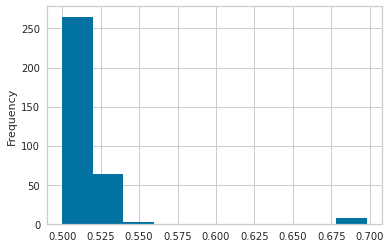

In [20]:
predictions['Score'].plot.hist()

In [21]:
# 결과 평가
(predictions['target']==predictions['Label'].replace({'False':False, 'True':True})).mean()

0.9023668639053254

In [22]:
predictions['Label'].replace({'False':False, 'True':True}).mean()

0.14792899408284024